# Forward Pass — NumpyGPT (with reference diagrams)

In [ ]:
import os
import rootutils
import numpy as np

rootutils.setup_root(os.path.abspath(''), indicator=['.git', 'pyproject.toml'], pythonpath=True)

from src.utils import load_encoder_hparams_and_params
from src.gpt2 import gpt2, gelu, softmax, layer_norm, linear, mha, ffn, transformer_block

In [ ]:
PROMPT = 'Computers can help'
encoder, hparams, params = load_encoder_hparams_and_params('124M', '../models')
print('hparams:', hparams)

---
## Diagram 1 — Token Embeddings

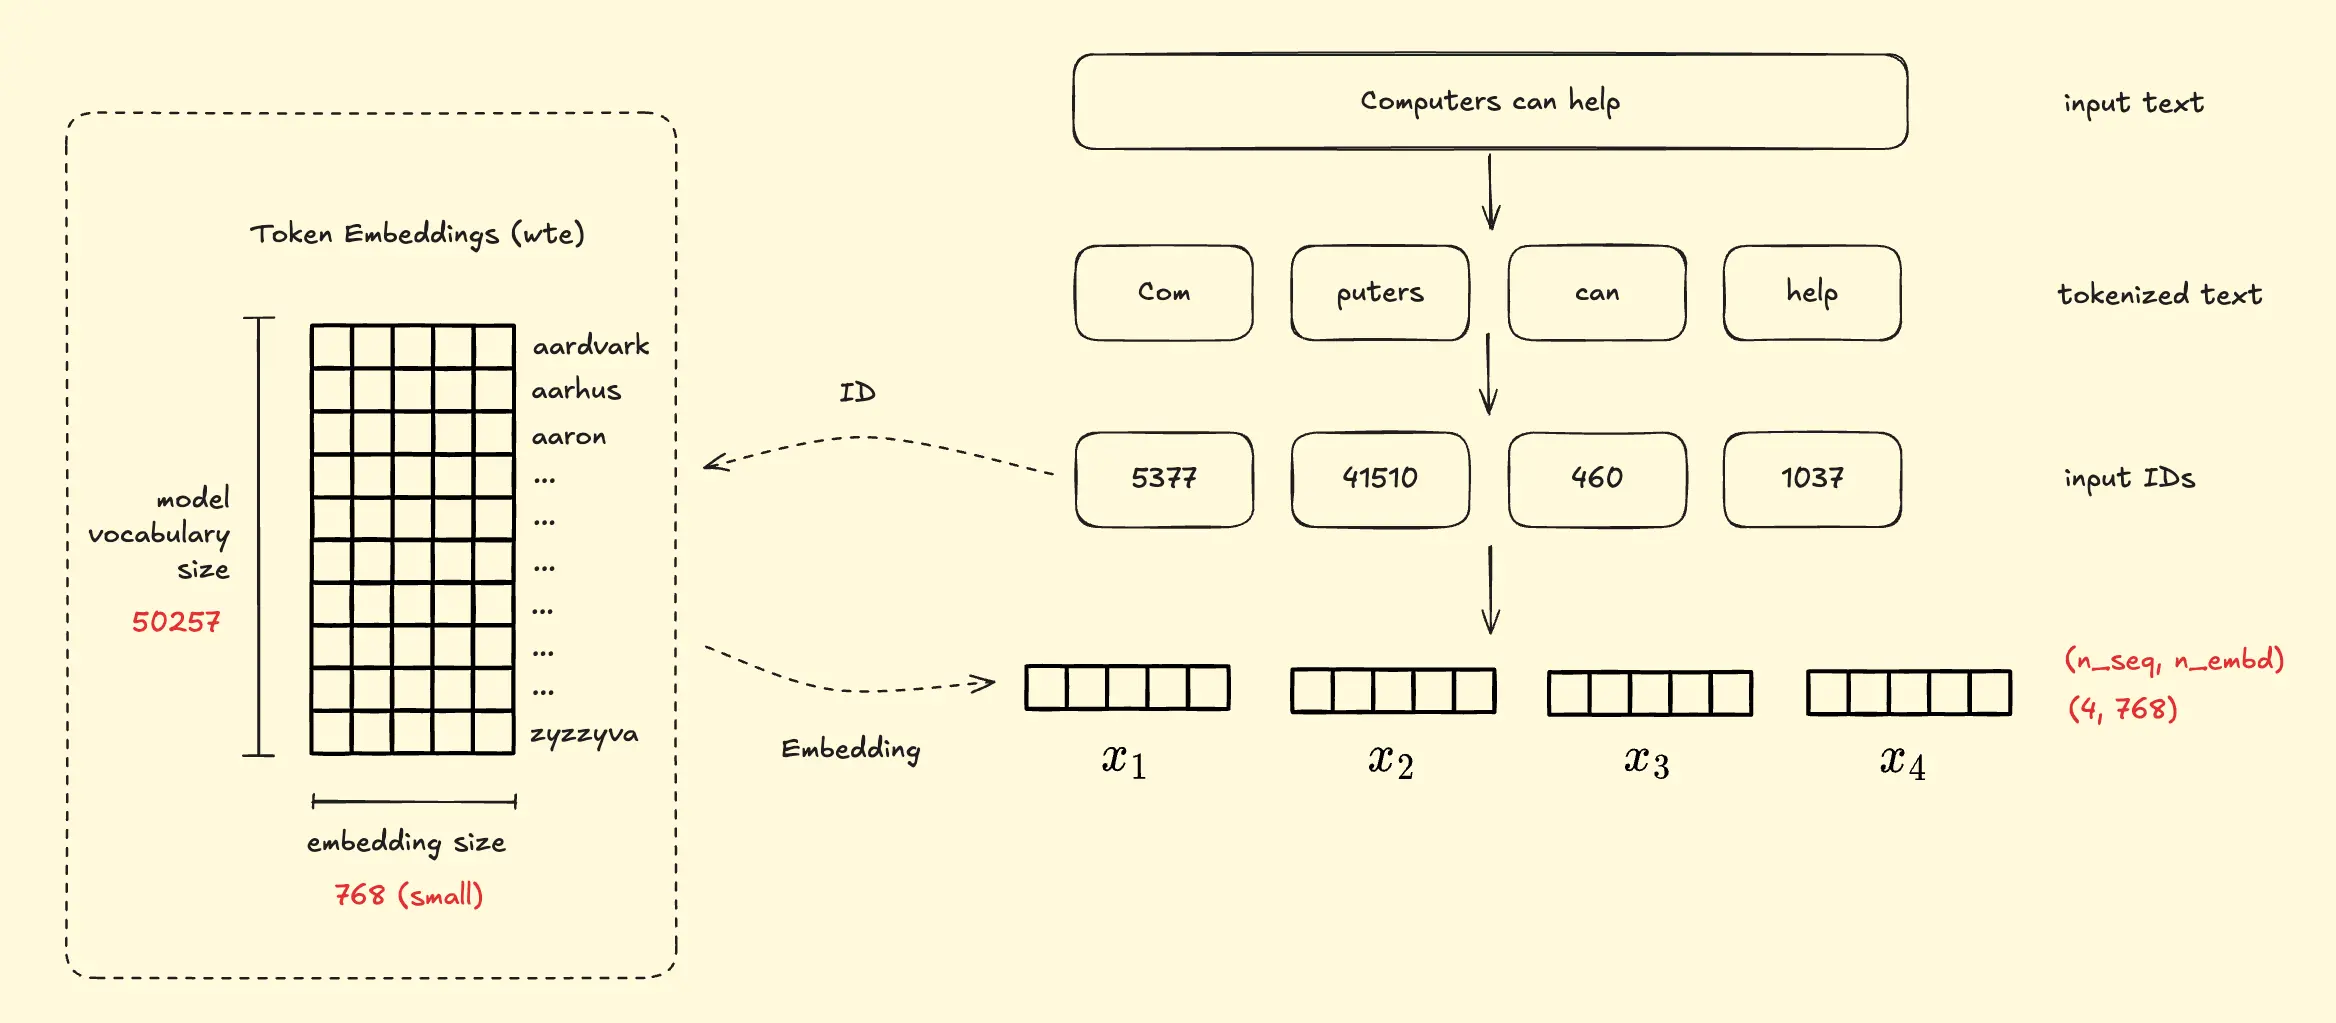

In [ ]:
input_ids = encoder.encode(PROMPT)
print('Prompt tokens:')
for idx in input_ids:
    print(f"  {idx:>6}  →  '{encoder.decode([idx])}'")

print(f'\ninput_ids shape : list of {len(input_ids)} ints')
print(f'wte shape       : {params["wte"].shape}  (vocab_size × n_embd)')

In [ ]:
token_emb = params['wte'][input_ids]
print(f'token_emb shape : {token_emb.shape}  (n_seq × n_embd)')
print(f"\nFirst token '{encoder.decode([input_ids[0]])}' embedding (first 8 values):")
print(np.round(token_emb[0, :8], 4))
print(f"\nLast token '{encoder.decode([input_ids[-1]])}' embedding (first 8 values):")
print(np.round(token_emb[-1, :8], 4))

---
## Diagram 2 — Positional Encodings

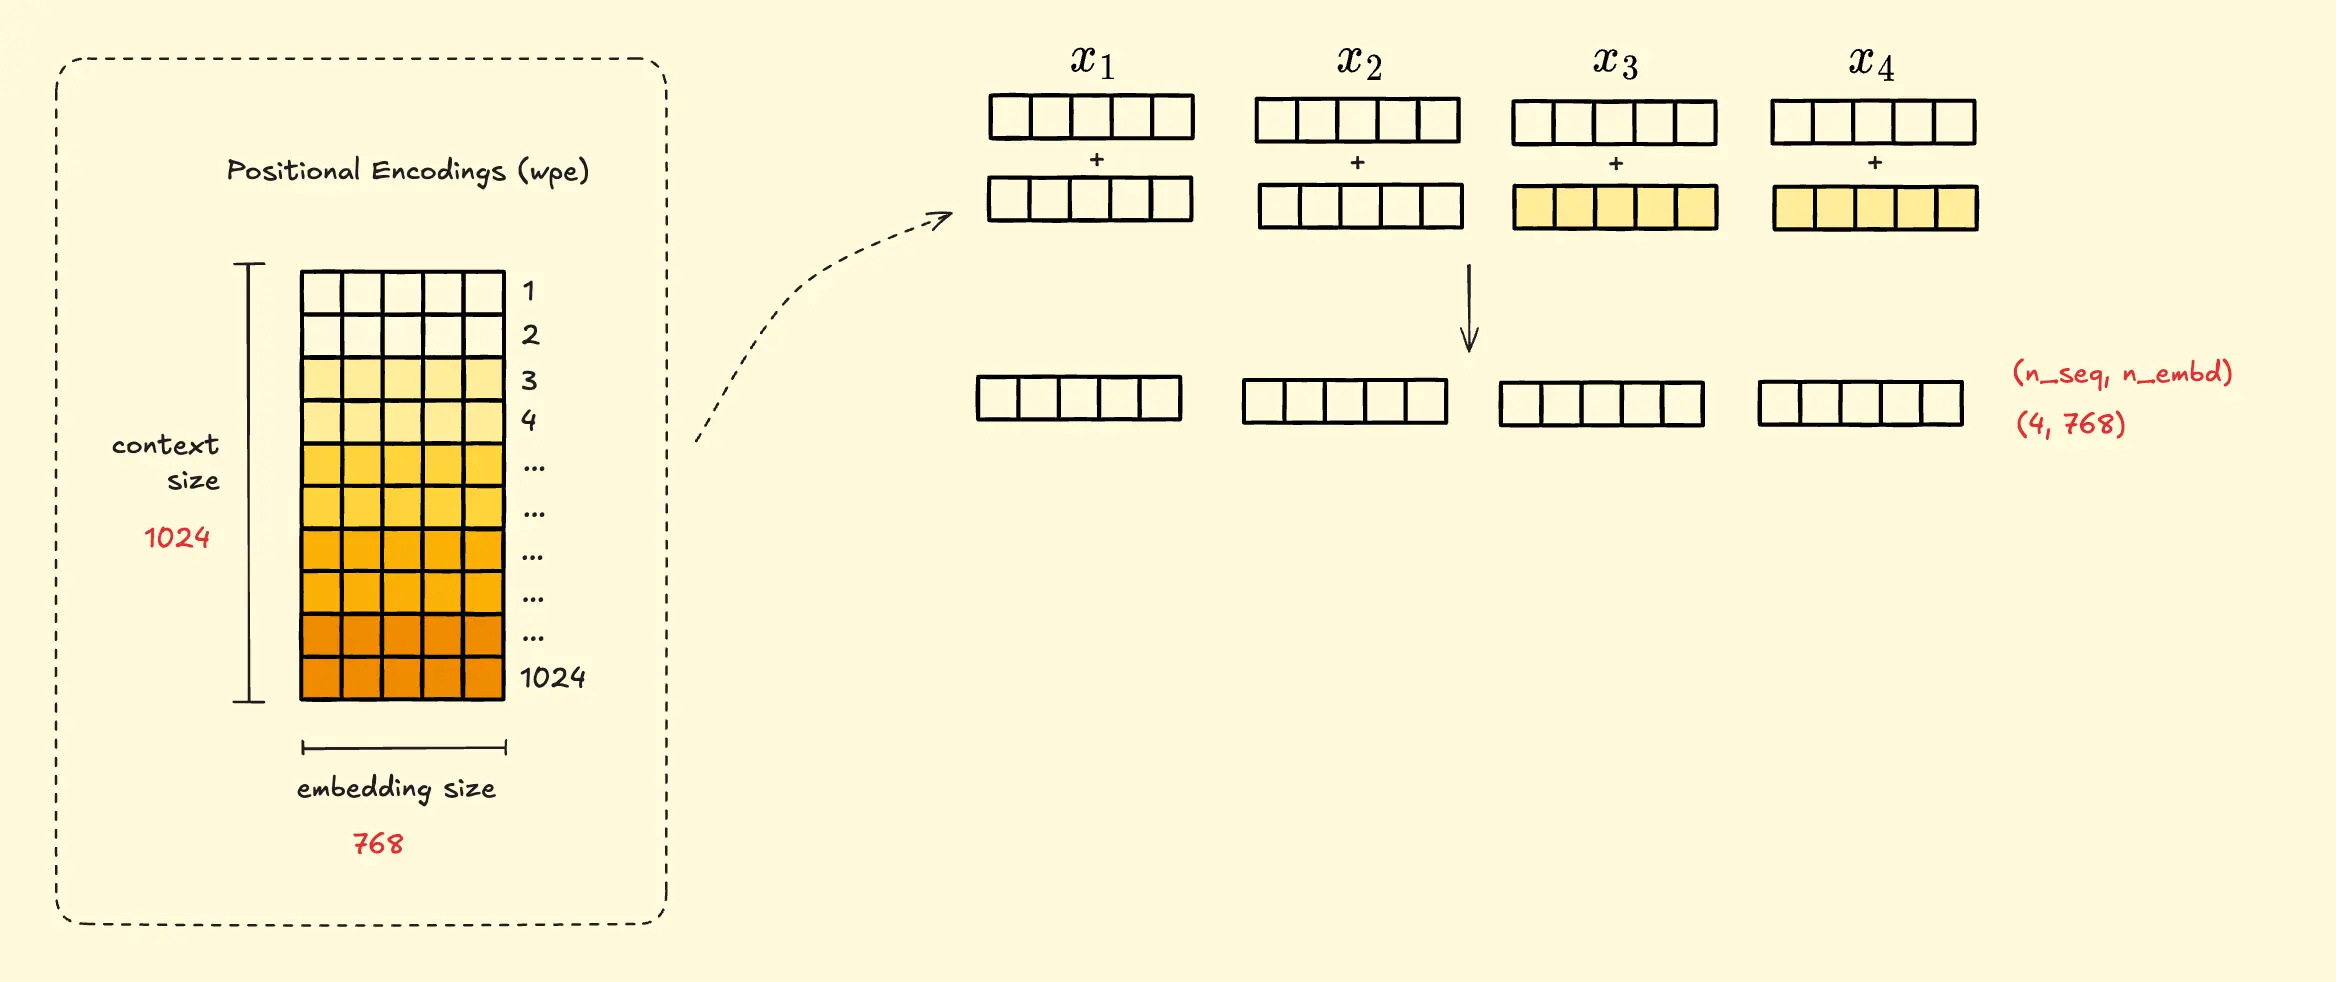

In [ ]:
n_seq = len(input_ids)
pos_emb = params['wpe'][range(n_seq)]

print(f'wpe shape       : {params["wpe"].shape}  (n_ctx × n_embd)')
print(f'pos_emb shape   : {pos_emb.shape}  (n_seq × n_embd)')
print(f'\nPosition 0 embedding (first 8 values):')
print(np.round(pos_emb[0, :8], 4))
print(f'\nPosition 1 embedding (first 8 values):')
print(np.round(pos_emb[1, :8], 4))

x = token_emb + pos_emb
print(f'\nx = token_emb + pos_emb')
print(f'x shape         : {x.shape}  (n_seq × n_embd)')
print(f'\nx[0] first 8 values (token + position combined):')
print(np.round(x[0, :8], 4))

---
## Diagram 3 — : Layer Norm & Linear

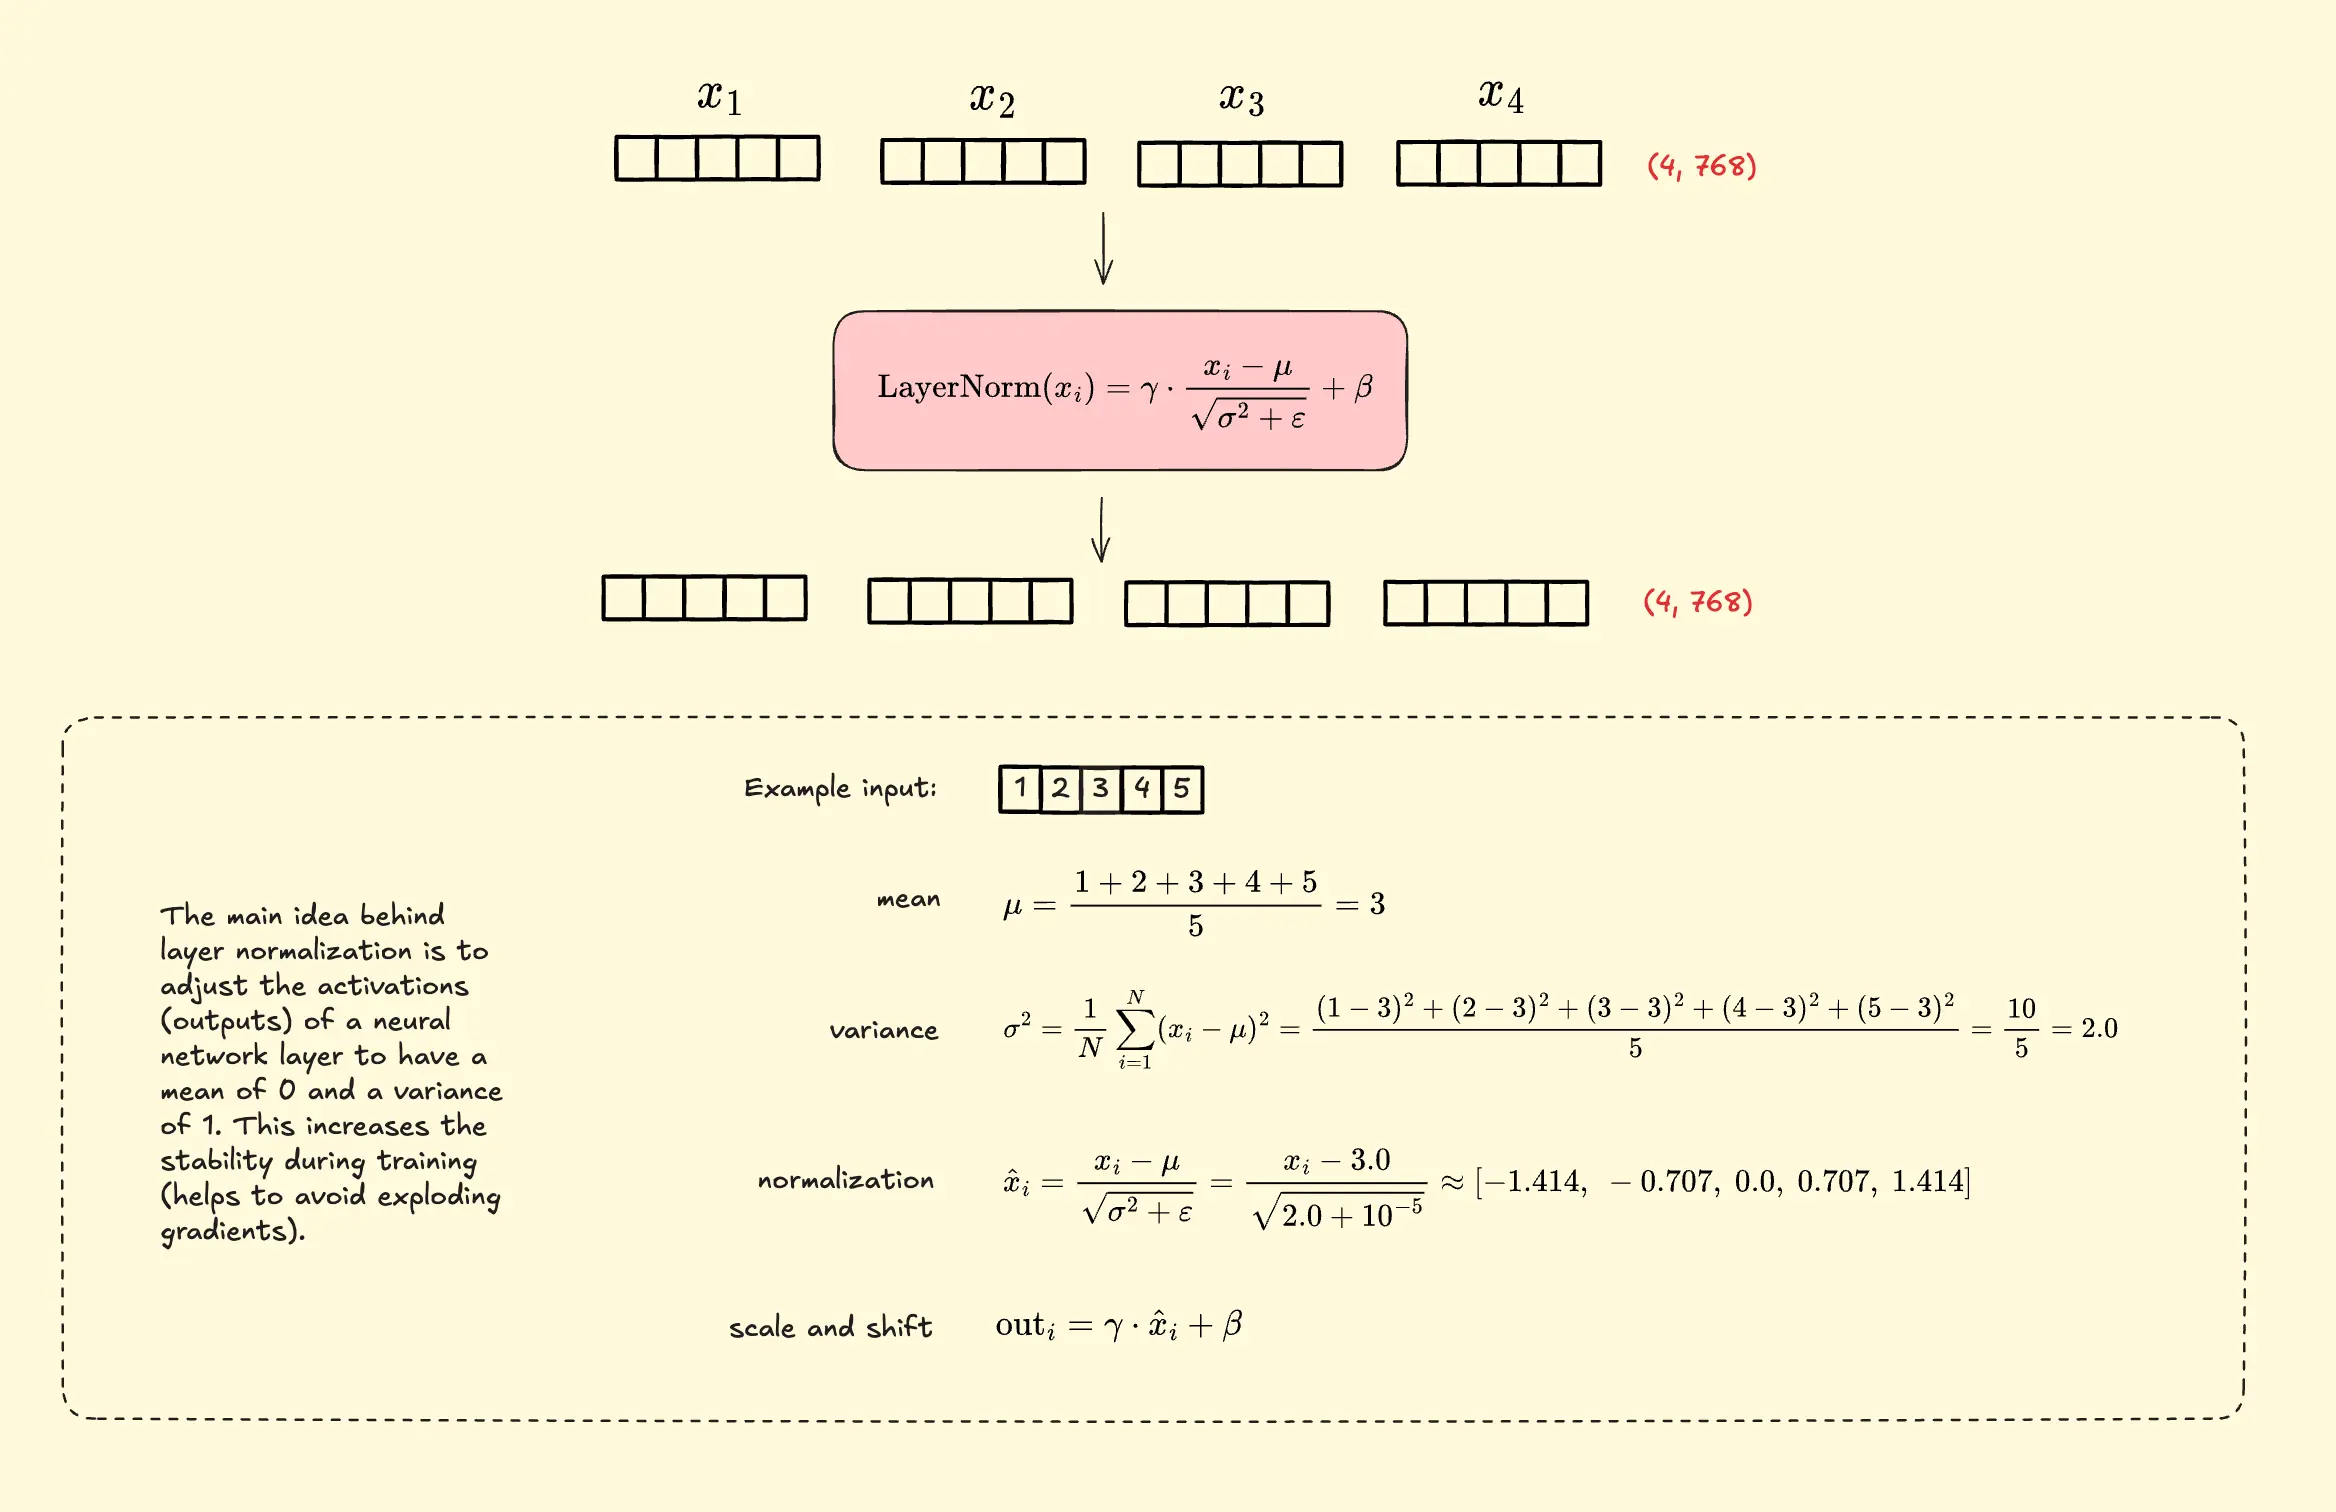

In [ ]:
# Layer Norm — step-by-step intermediate calculations (token 0)
ln1 = params['blocks'][0]['ln_1']
eps = 1e-5

print('=== Layer Norm — Step by Step (token 0) ===')
print(f'Input x[0] first 8 values:')
print(np.round(x[0, :8], 4))

# Step 1: mean
mu = x[0].mean()
print(f'\nStep 1 — μ = mean(x[0]) = {mu:.6f}  (avg of {x.shape[1]} values)')

# Step 2: variance
var = x[0].var()
print(f'Step 2 — σ² = var(x[0])  = {var:.6f}')
print(f'         σ  = std(x[0])  = {np.sqrt(var):.6f}')

# Step 3: normalize
x_hat = (x[0] - mu) / np.sqrt(var + eps)
print(f'\nStep 3 — x̂ = (x - μ) / √(σ² + ε),  ε={eps}')
print(f'x̂ first 8 values : {np.round(x_hat[:8], 4)}')
print(f'x̂ mean           : {x_hat.mean():.8f}  (≈ 0)')
print(f'x̂ std            : {x_hat.std():.8f}   (≈ 1)')

# Step 4: scale and shift
gamma, beta = ln1['g'], ln1['b']
out_manual = gamma * x_hat + beta
print(f'\nStep 4 — out = γ·x̂ + β')
print(f'γ   first 8 : {np.round(gamma[:8], 4)}')
print(f'β   first 8 : {np.round(beta[:8], 4)}')
print(f'out first 8 : {np.round(out_manual[:8], 4)}')

# Compare with layer_norm()
x_ln = layer_norm(x, **ln1)
print(f'\n--- manual vs layer_norm() ---')
print(f'Manual      [0,:8] : {np.round(out_manual[:8], 6)}')
print(f'layer_norm()[0,:8] : {np.round(x_ln[0, :8], 6)}')
print(f'Match: {np.allclose(out_manual, x_ln[0])}')
print(f'\nFull output shape : {x_ln.shape}')
print(f'Before — x[0]    mean={x[0].mean():.4f}  std={x[0].std():.4f}')
print(f'After  — x_ln[0] mean={x_ln[0].mean():.6f}  std={x_ln[0].std():.6f}')

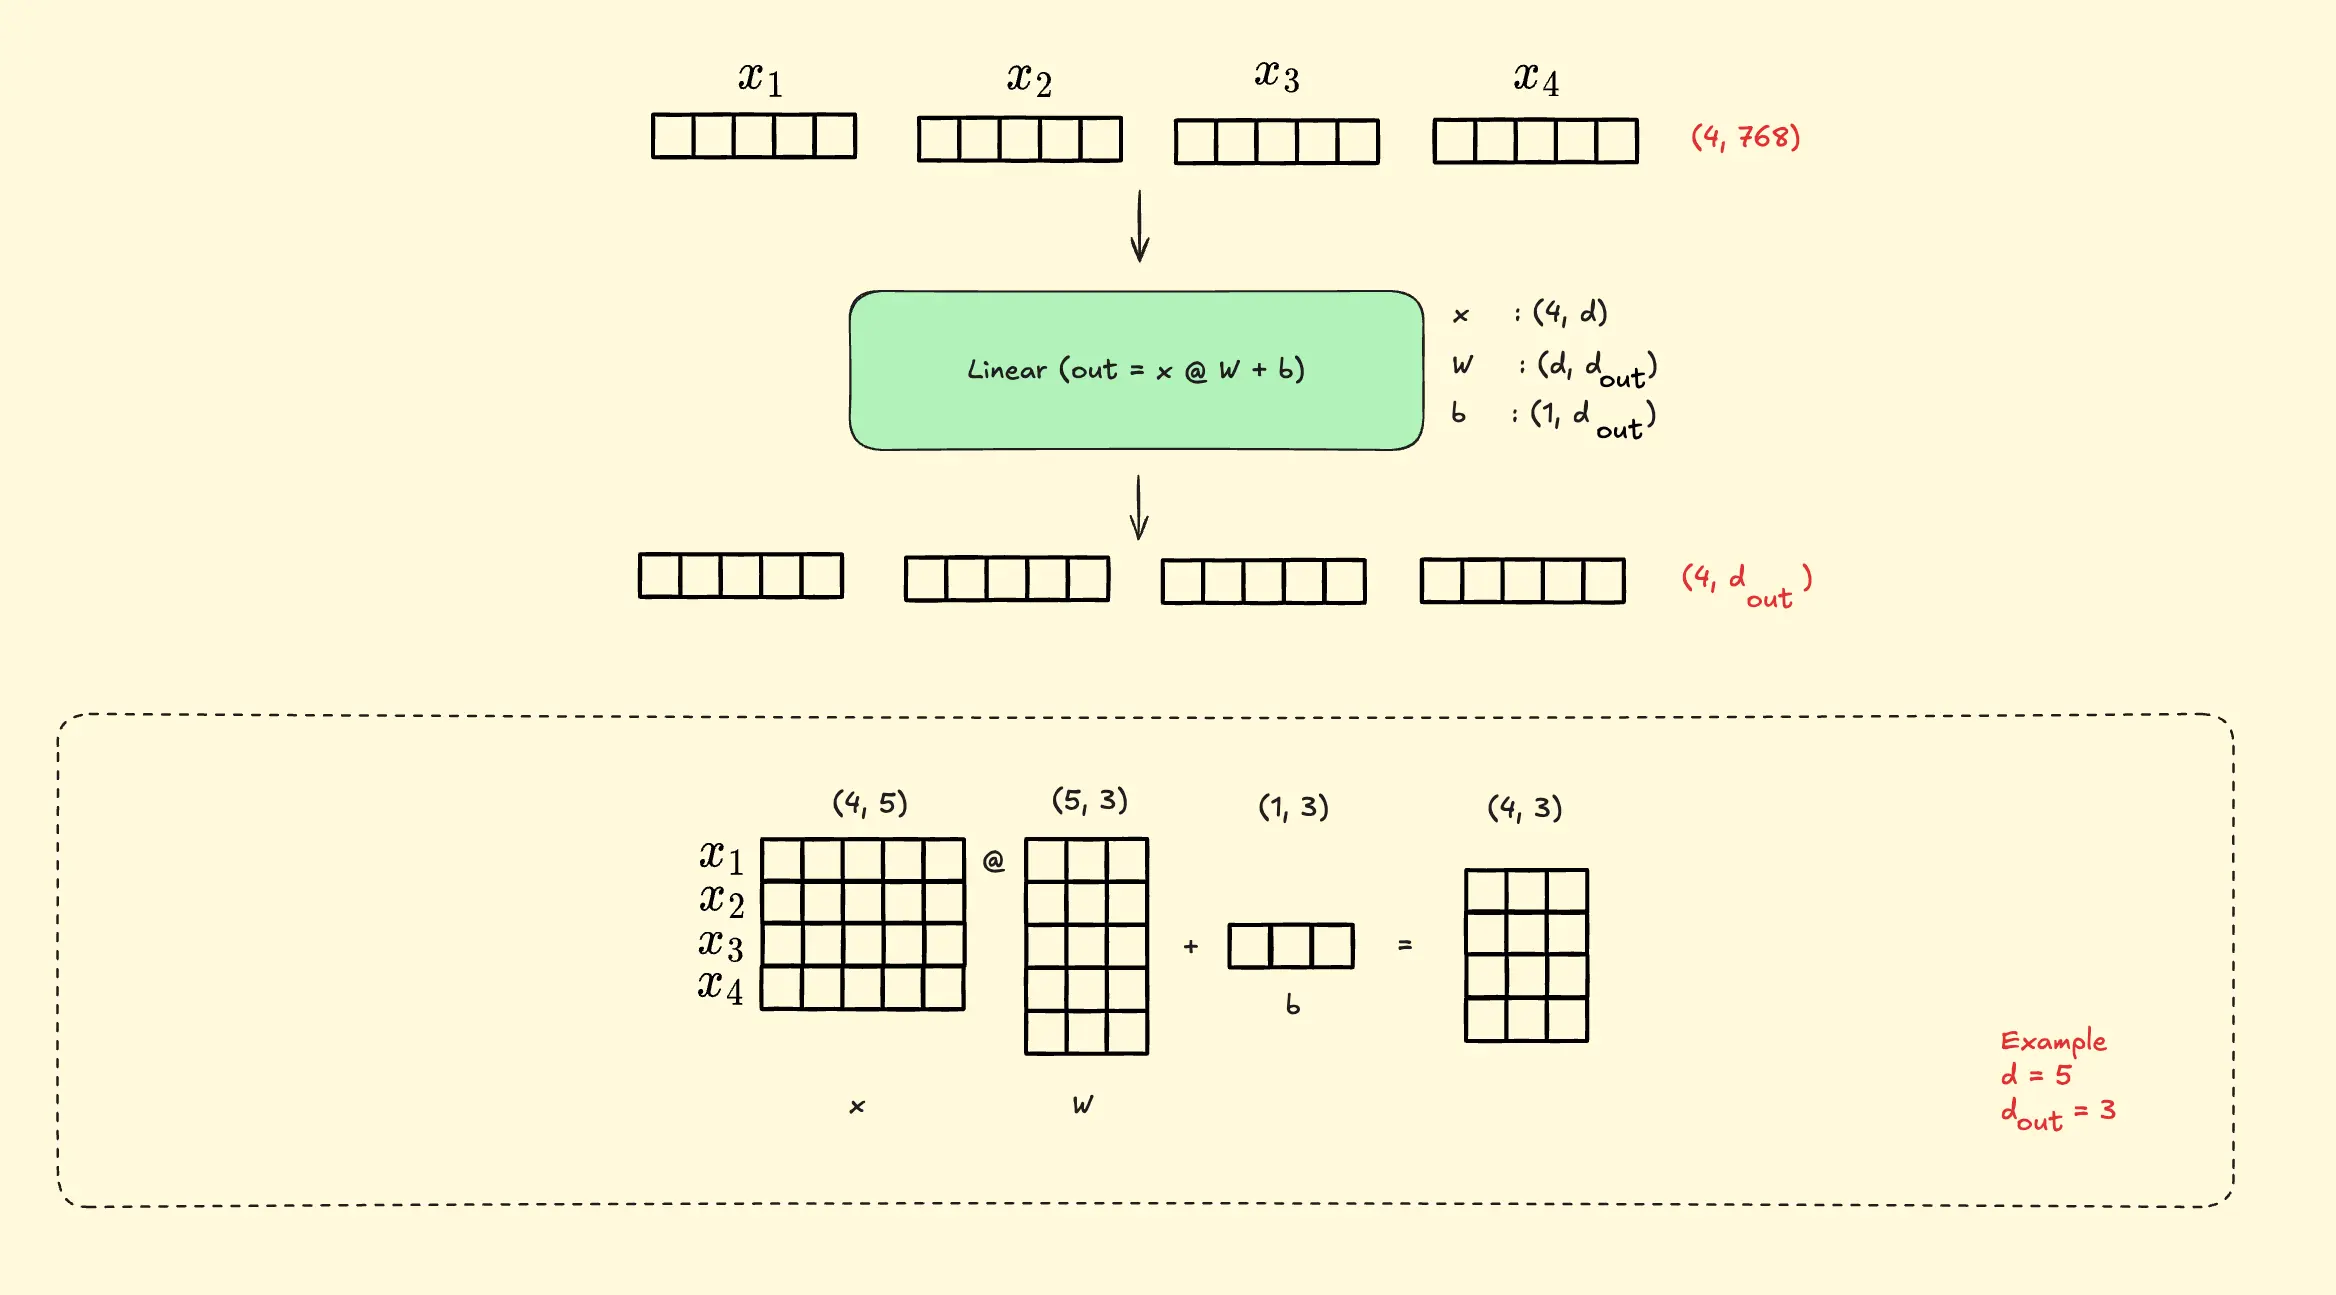

In [ ]:
# Linear — step-by-step (block 0, MLP c_fc: 768 → 3072)
x_ln = layer_norm(x, **params['blocks'][0]['ln_1'])
c_fc = params['blocks'][0]['mlp']['c_fc']

print('=== Linear — Step by Step ===')
print(f'x    : {x_ln.shape}   (n_seq × n_embd)')
print(f'W    : {c_fc["w"].shape}  (n_embd × 4*n_embd)')
print(f'b    : {c_fc["b"].shape}     (4*n_embd)')
print(f'\nout = x @ W + b')

# Manual
out_xW = x_ln @ c_fc['w']
out_manual = out_xW + c_fc['b']

print(f'\nx @ W       shape : {out_xW.shape}')
print(f'x @ W + b   shape : {out_manual.shape}')
print(f'\nx_ln[0, :4]     : {np.round(x_ln[0, :4], 4)}  ... (768 values)')
print(f'W[:4, :4]       :\n{np.round(c_fc["w"][:4, :4], 4)}')
print(f'b[:4]           : {np.round(c_fc["b"][:4], 4)}')
print(f'\nout[0, :8]      : {np.round(out_manual[0, :8], 4)}')

# Compare with linear()
out_fn = linear(x_ln, **c_fc)
print(f'\n--- manual vs linear() ---')
print(f'Manual   [0,:8] : {np.round(out_manual[0, :8], 6)}')
print(f'linear() [0,:8] : {np.round(out_fn[0, :8], 6)}')
print(f'Match: {np.allclose(out_manual, out_fn)}')

---
## Diagram 4 — Single-Head Attention

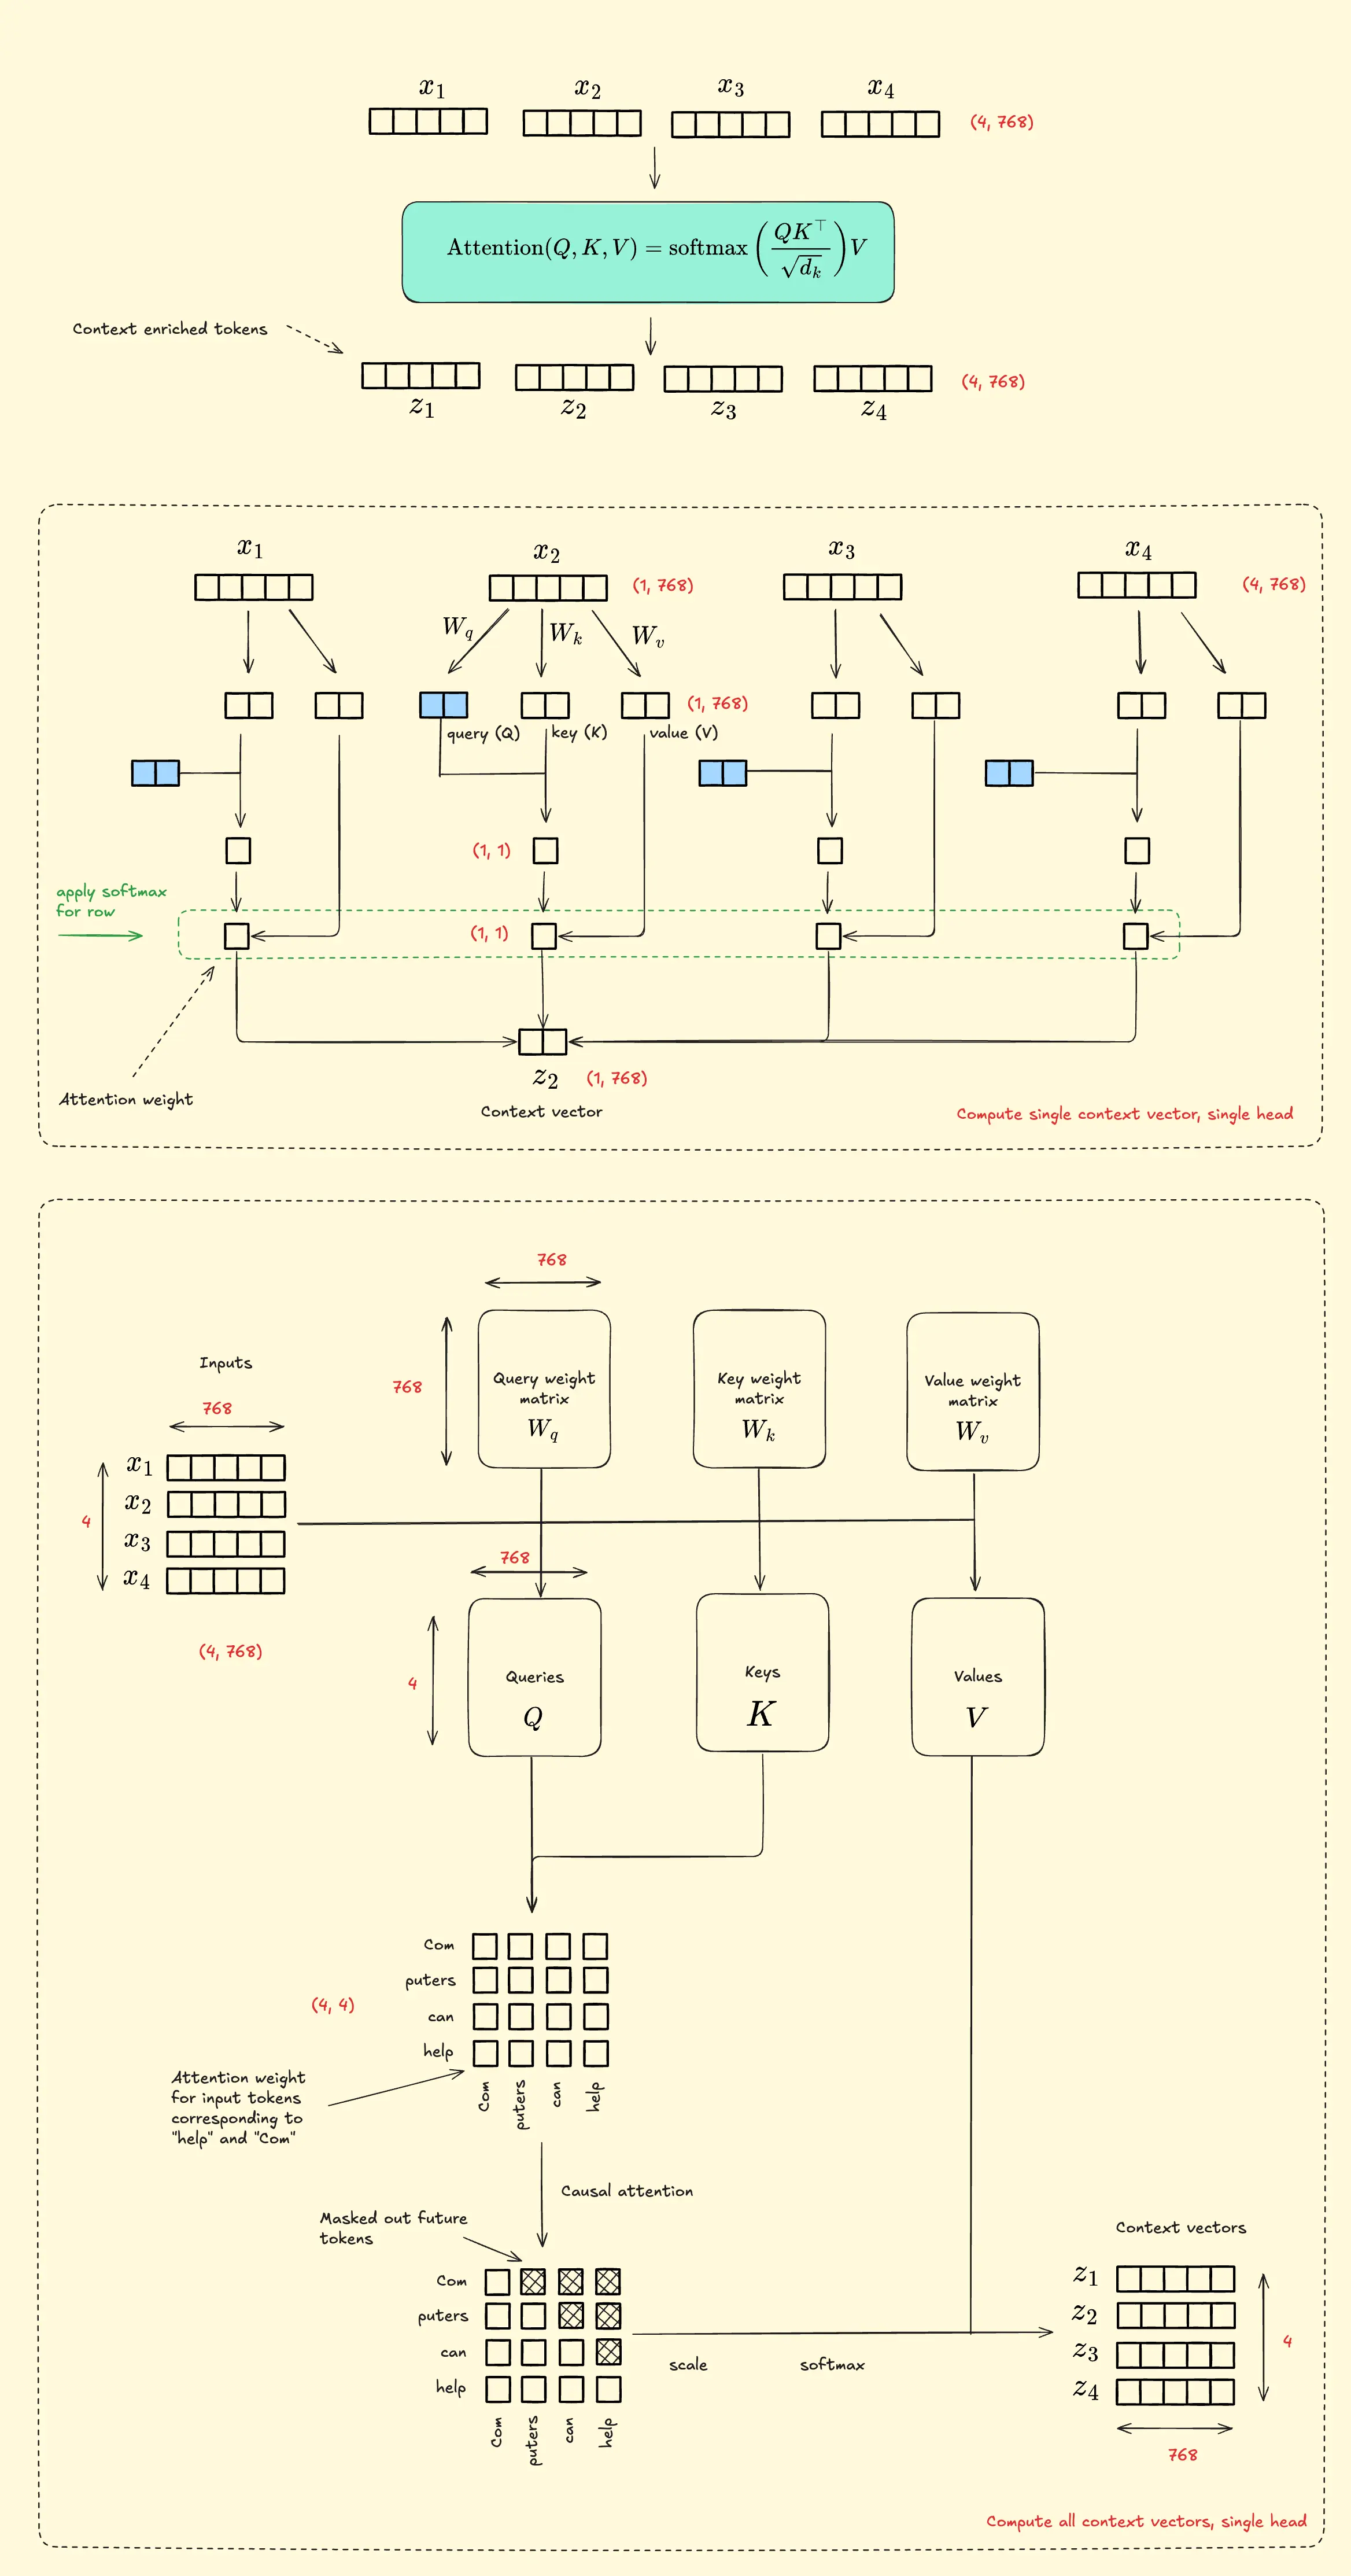

In [ ]:
n_head = hparams['n_head']  # 12
n_embd = hparams['n_embd']  # 768
d_head = n_embd // n_head  # 64

attn_weights = params['blocks'][0]['attn']
x_ln = layer_norm(x, **params['blocks'][0]['ln_1'])

# QKV projection
qkv = linear(x_ln, **attn_weights['c_attn'])
print(f'After c_attn projection: {qkv.shape}  (n_seq × 3*n_embd)')

Q, K, V = np.split(qkv, 3, axis=-1)
print(f'Q shape: {Q.shape}  K shape: {K.shape}  V shape: {V.shape}')

# Extract head 0
Q0 = Q[:, :d_head]
K0 = K[:, :d_head]
V0 = V[:, :d_head]
print(f'\nHead 0 — Q0: {Q0.shape}  K0: {K0.shape}  V0: {V0.shape}')

In [ ]:
# Scores before mask
scores_raw = Q0 @ K0.T / np.sqrt(d_head)
print(f'scores = Q @ K.T / sqrt({d_head})')
print(f'scores shape    : {scores_raw.shape}  (n_seq × n_seq)')
print(f'\nRaw scores (rounded):')
print(np.round(scores_raw, 2))

# Causal mask
causal_mask = (1 - np.tri(n_seq, dtype=x.dtype)) * -1e10
print(f'\nCausal mask:')
print(causal_mask)

# Attention weights
attn_weights_out = softmax(scores_raw + causal_mask)
print(f'\nAttention weights after softmax (rows sum to 1.0):')
print(np.round(attn_weights_out, 3))
print(f'Row sums: {np.round(attn_weights_out.sum(axis=-1), 4)}')

# Output
head0_out = attn_weights_out @ V0
print(f'\nHead 0 output shape: {head0_out.shape}  (n_seq × d_head)')

---
## Diagram 5 — Multi-Head Causal Self-Attention (full)

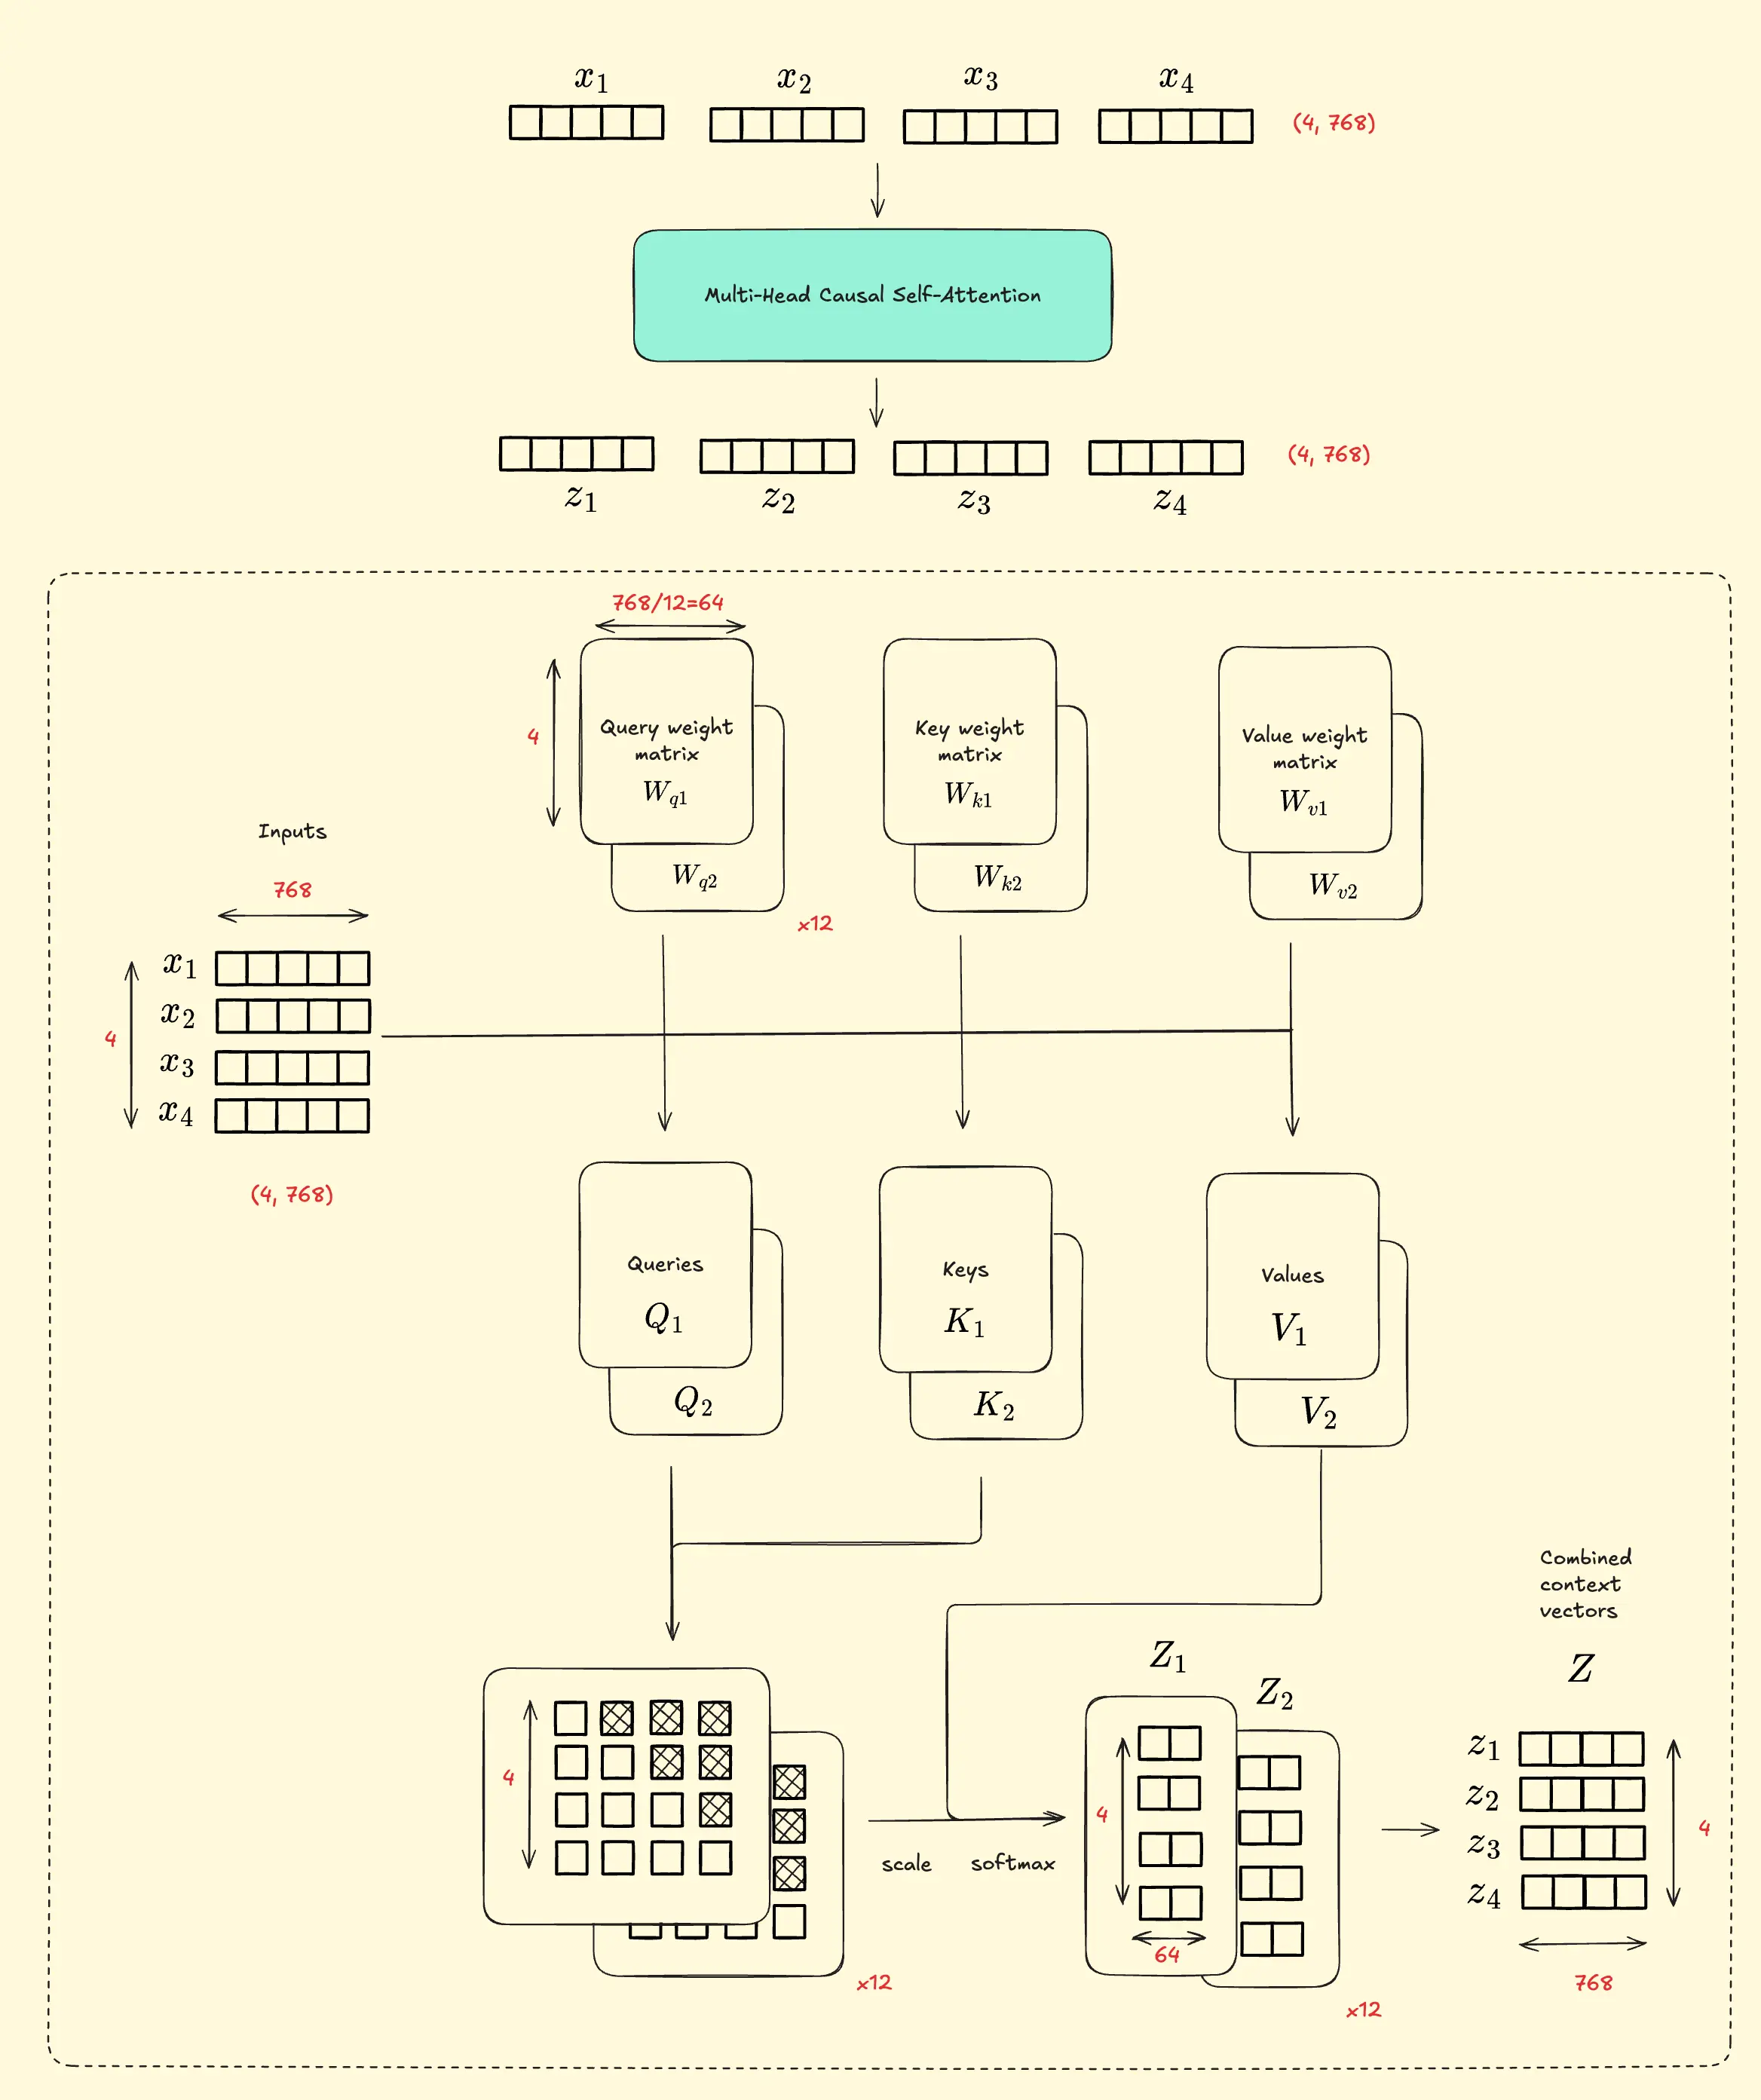

In [ ]:
attn_params = params['blocks'][0]['attn']
x_ln = layer_norm(x, **params['blocks'][0]['ln_1'])

print('=== MHA weight shapes ===')
print(f'c_attn.w : {attn_params["c_attn"]["w"].shape}  (n_embd → 3*n_embd)')
print(f'c_attn.b : {attn_params["c_attn"]["b"].shape}')
print(f'c_proj.w : {attn_params["c_proj"]["w"].shape}  (n_embd → n_embd)')
print(f'c_proj.b : {attn_params["c_proj"]["b"].shape}')

mha_out = mha(x_ln, **attn_params, n_head=n_head)
print(f'\nMHA input  shape : {x_ln.shape}')
print(f'MHA output shape : {mha_out.shape}')

print(f'\nn_head={n_head}, d_head={d_head}  →  {n_head} × {d_head} = {n_head * d_head} = n_embd')

---
## Diagram 6 — Feed-Forward Network

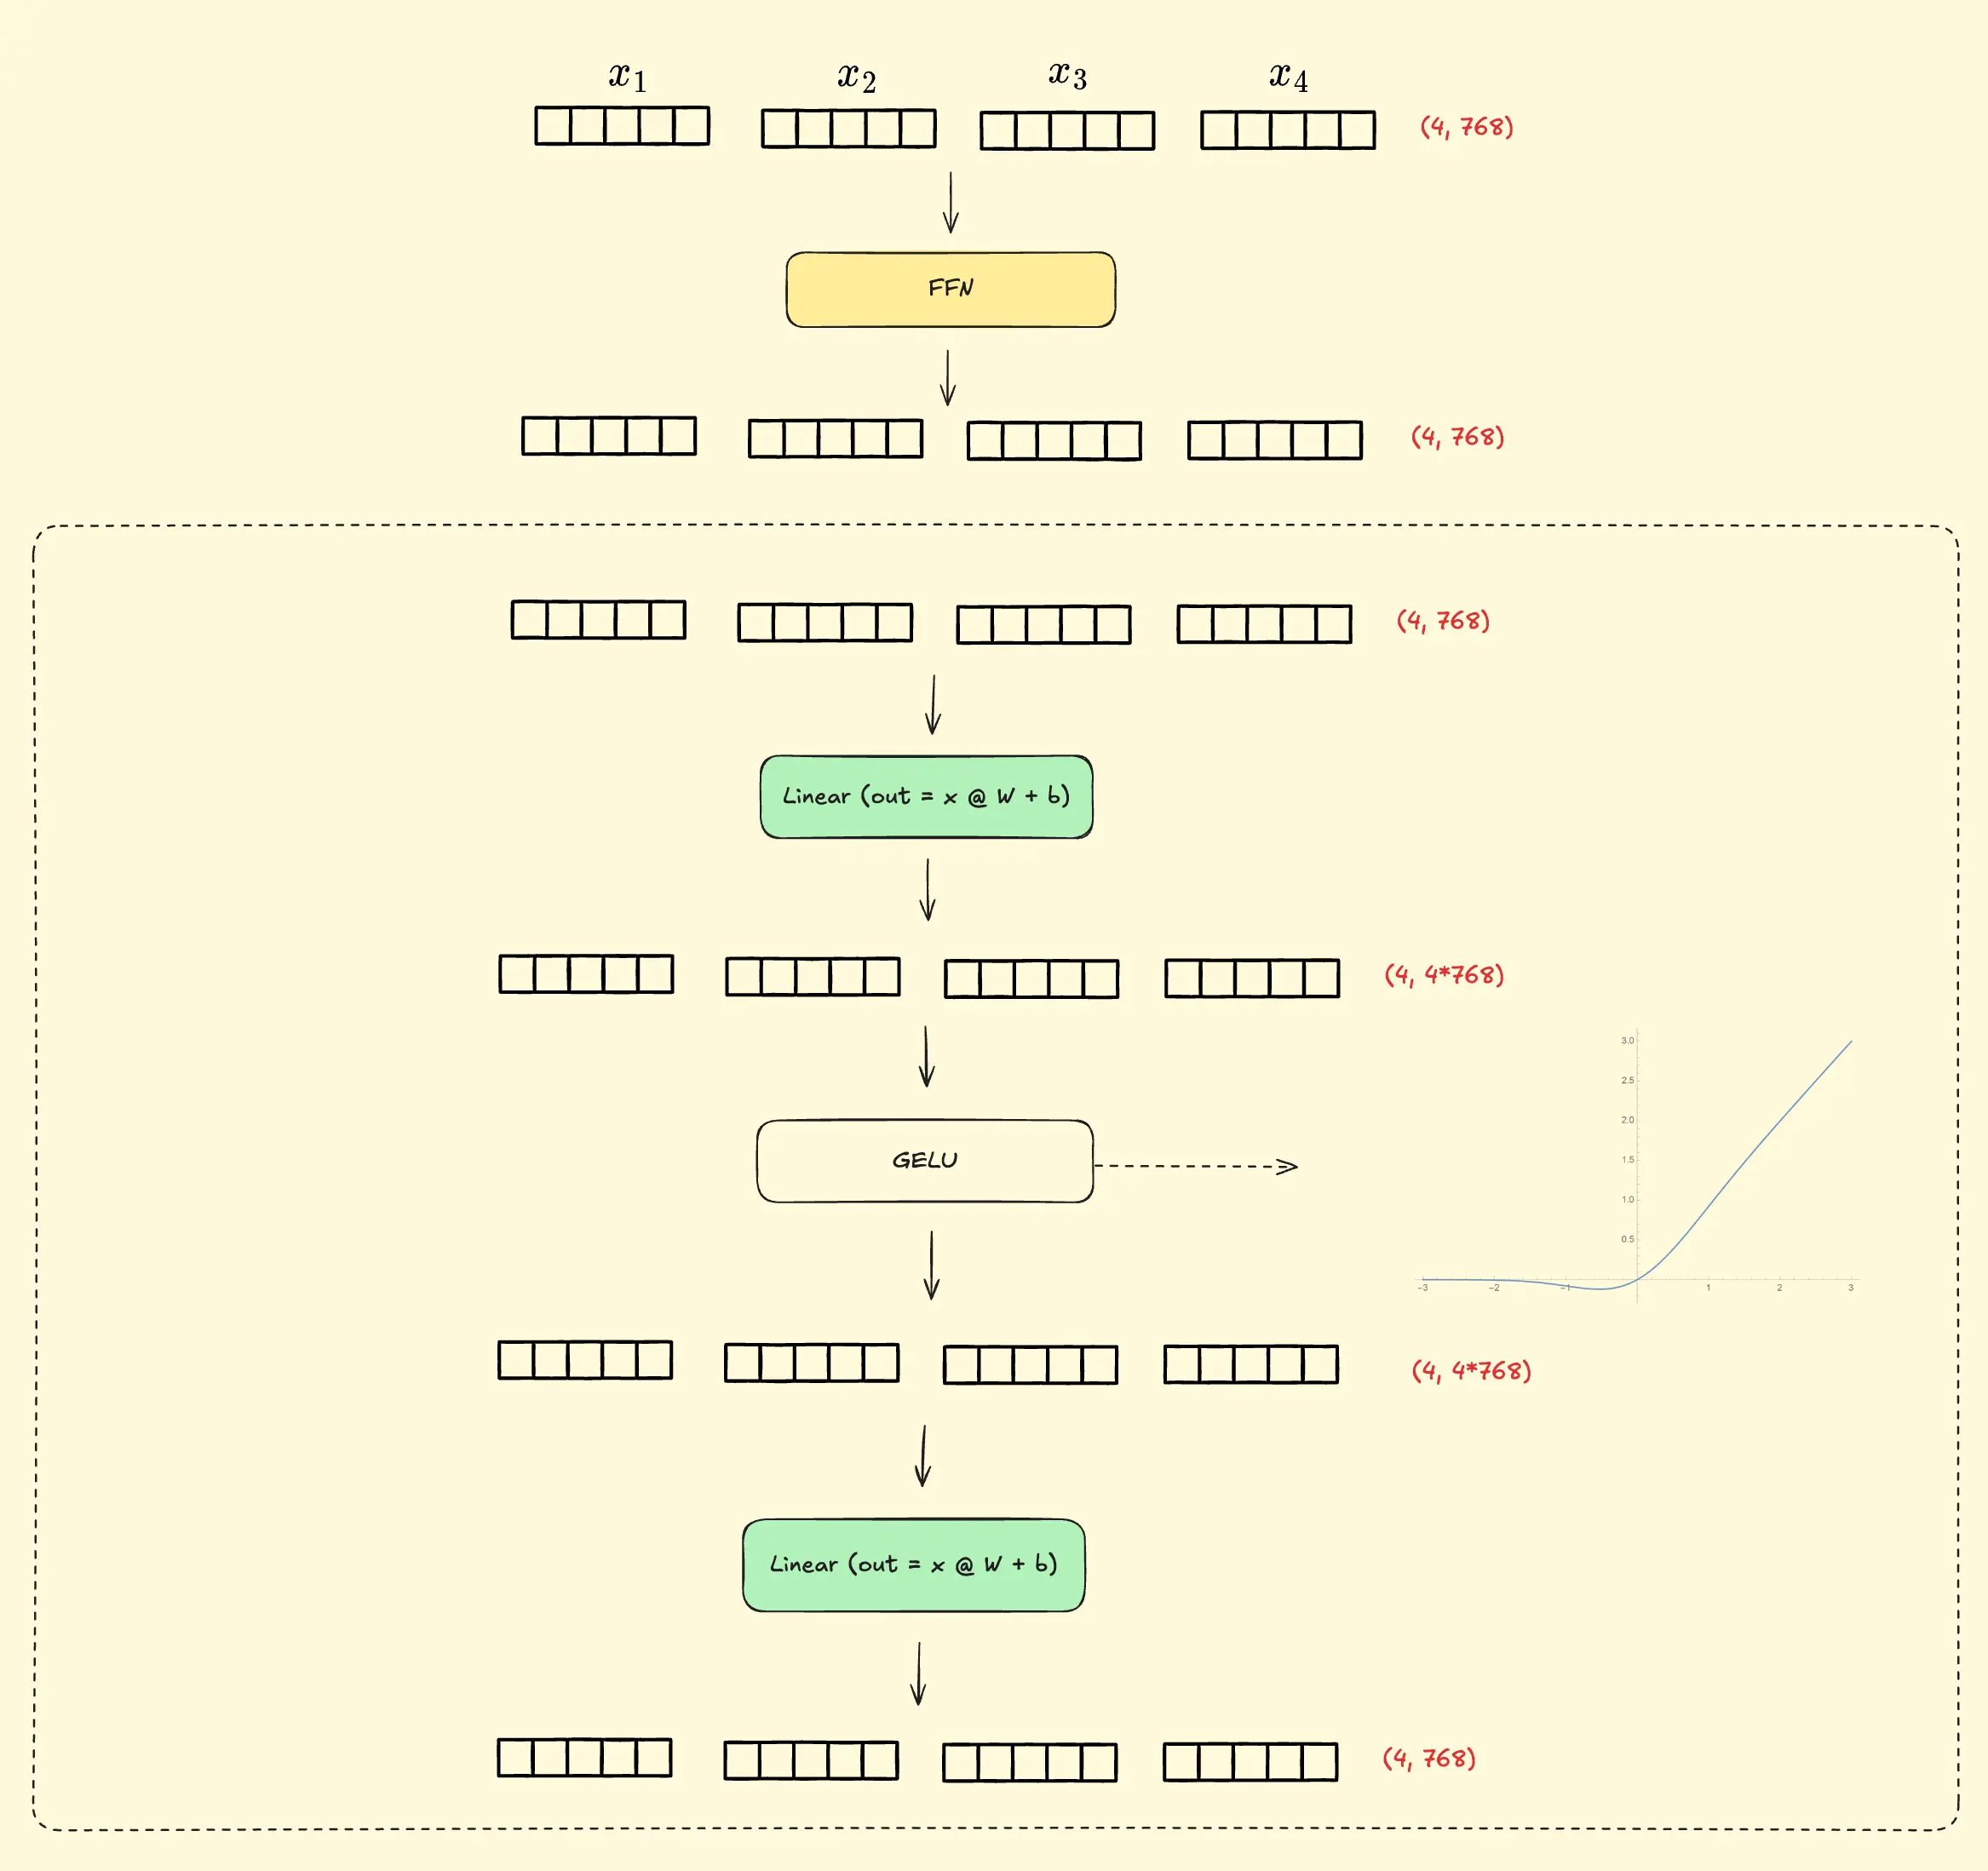

In [ ]:
mlp_params = params['blocks'][0]['mlp']
x_ln2 = layer_norm(x, **params['blocks'][0]['ln_2'])

print('=== FFN weight shapes ===')
print(f'c_fc.w   : {mlp_params["c_fc"]["w"].shape}   (n_embd → 4*n_embd)')
print(f'c_fc.b   : {mlp_params["c_fc"]["b"].shape}')
print(f'c_proj.w : {mlp_params["c_proj"]["w"].shape}  (4*n_embd → n_embd)')
print(f'c_proj.b : {mlp_params["c_proj"]["b"].shape}')

# Step through manually
after_fc = linear(x_ln2, **mlp_params['c_fc'])
after_gelu = gelu(after_fc)
after_proj = linear(after_gelu, **mlp_params['c_proj'])

print(f'\nInput          : {x_ln2.shape}')
print(f'After c_fc     : {after_fc.shape}  (4× expansion)')
print(f'After gelu     : {after_gelu.shape}')
print(f'After c_proj   : {after_proj.shape}  (back to n_embd)')

# Show GELU effect on a small sample
sample = np.array([-3.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0])
print(f'\nGELU sample:')
for v in sample:
    print(f'  gelu({v:+.1f}) = {gelu(v):+.4f}')

---
## Diagram 7 — Transformer Block

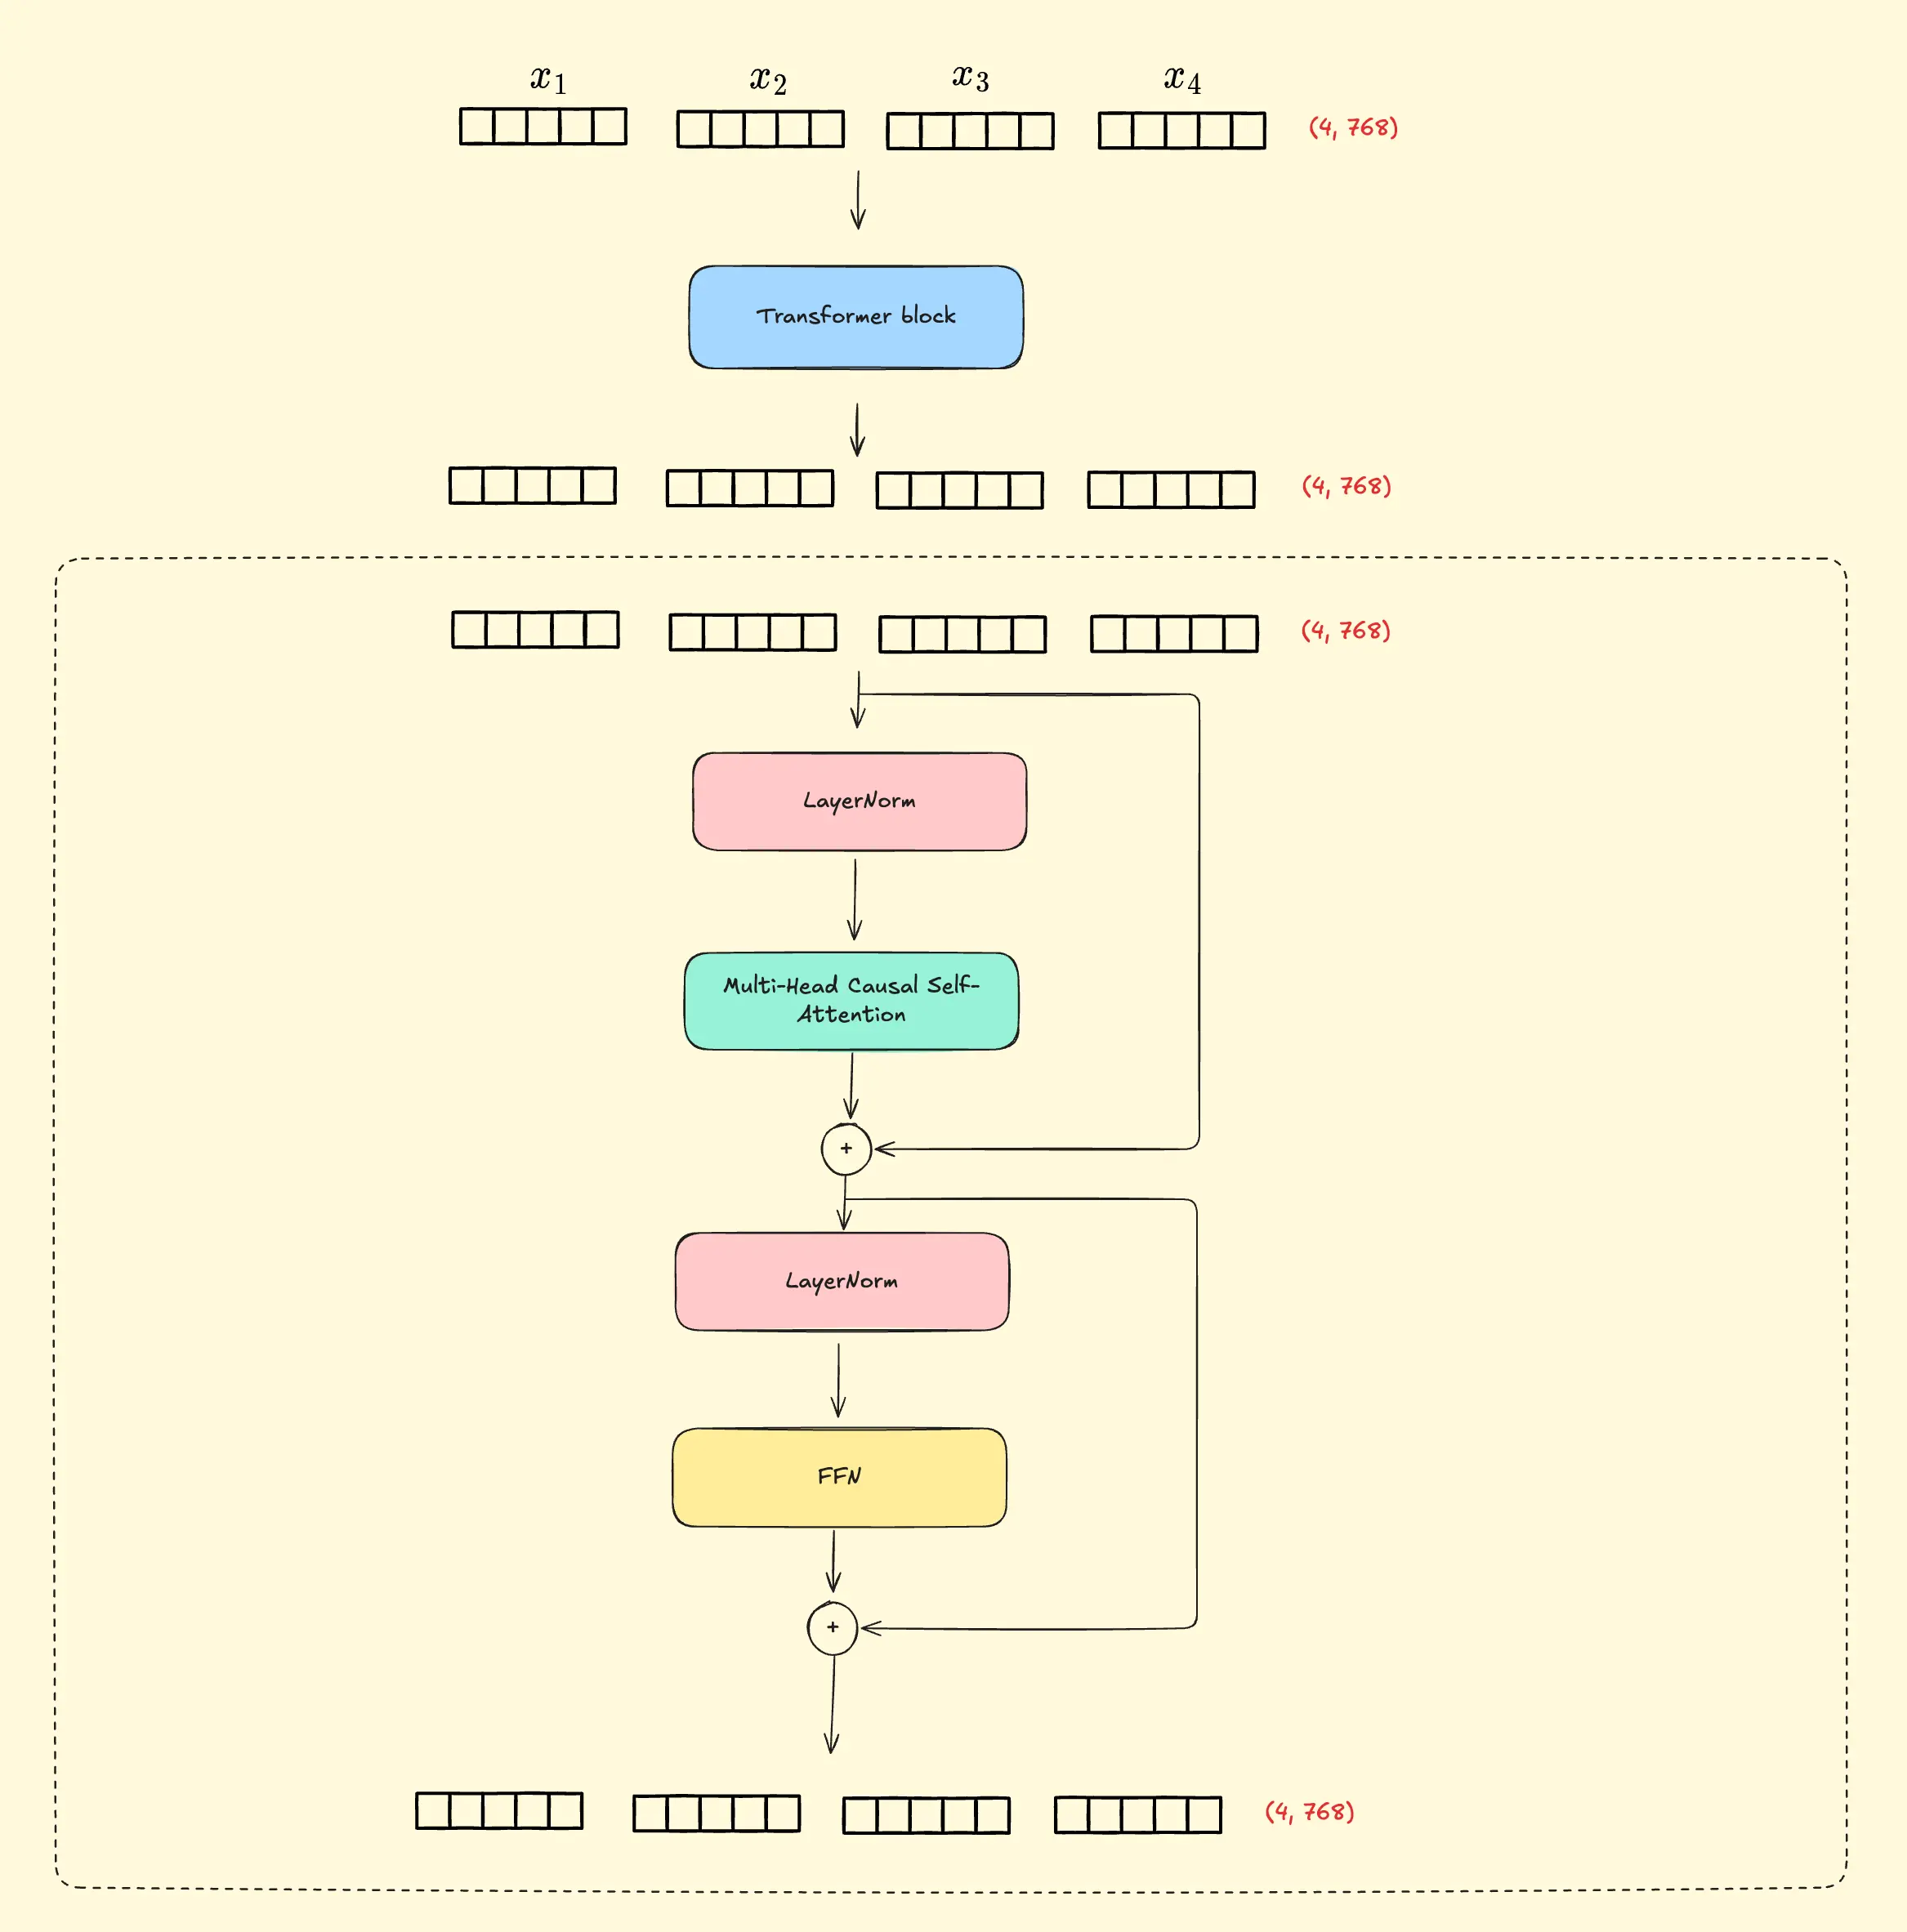

In [ ]:
block0 = params['blocks'][0]

print(f'Block 0 keys     : {list(block0.keys())}')
print(f'\nInput  x shape   : {x.shape}')

# Residual 1: MHA
x_normed1 = layer_norm(x, **block0['ln_1'])
mha_out = mha(x_normed1, **block0['attn'], n_head=n_head)
x_after_attn = x + mha_out  # residual add
print(f'After attn resid : {x_after_attn.shape}  (x + mha_out)')

# Residual 2: FFN
x_normed2 = layer_norm(x_after_attn, **block0['ln_2'])
ffn_out = ffn(x_normed2, **block0['mlp'])
x_after_ffn = x_after_attn + ffn_out  # residual add
print(f'After ffn  resid : {x_after_ffn.shape}  (x + ffn_out)')

# Same result via transformer_block()
x_block = transformer_block(x, **block0, n_head=n_head)
print(f'\nVia transformer_block(): {x_block.shape}')
print(f'Results match: {np.allclose(x_after_ffn, x_block)}')

print(f'\nResidual effect — how much did MHA change x?')
print(f'  mean |mha_out| = {np.abs(mha_out).mean():.4f}')
print(f'  mean |x|       = {np.abs(x).mean():.4f}')

---
## Diagram 8 — Full GPT-2 Forward Pass

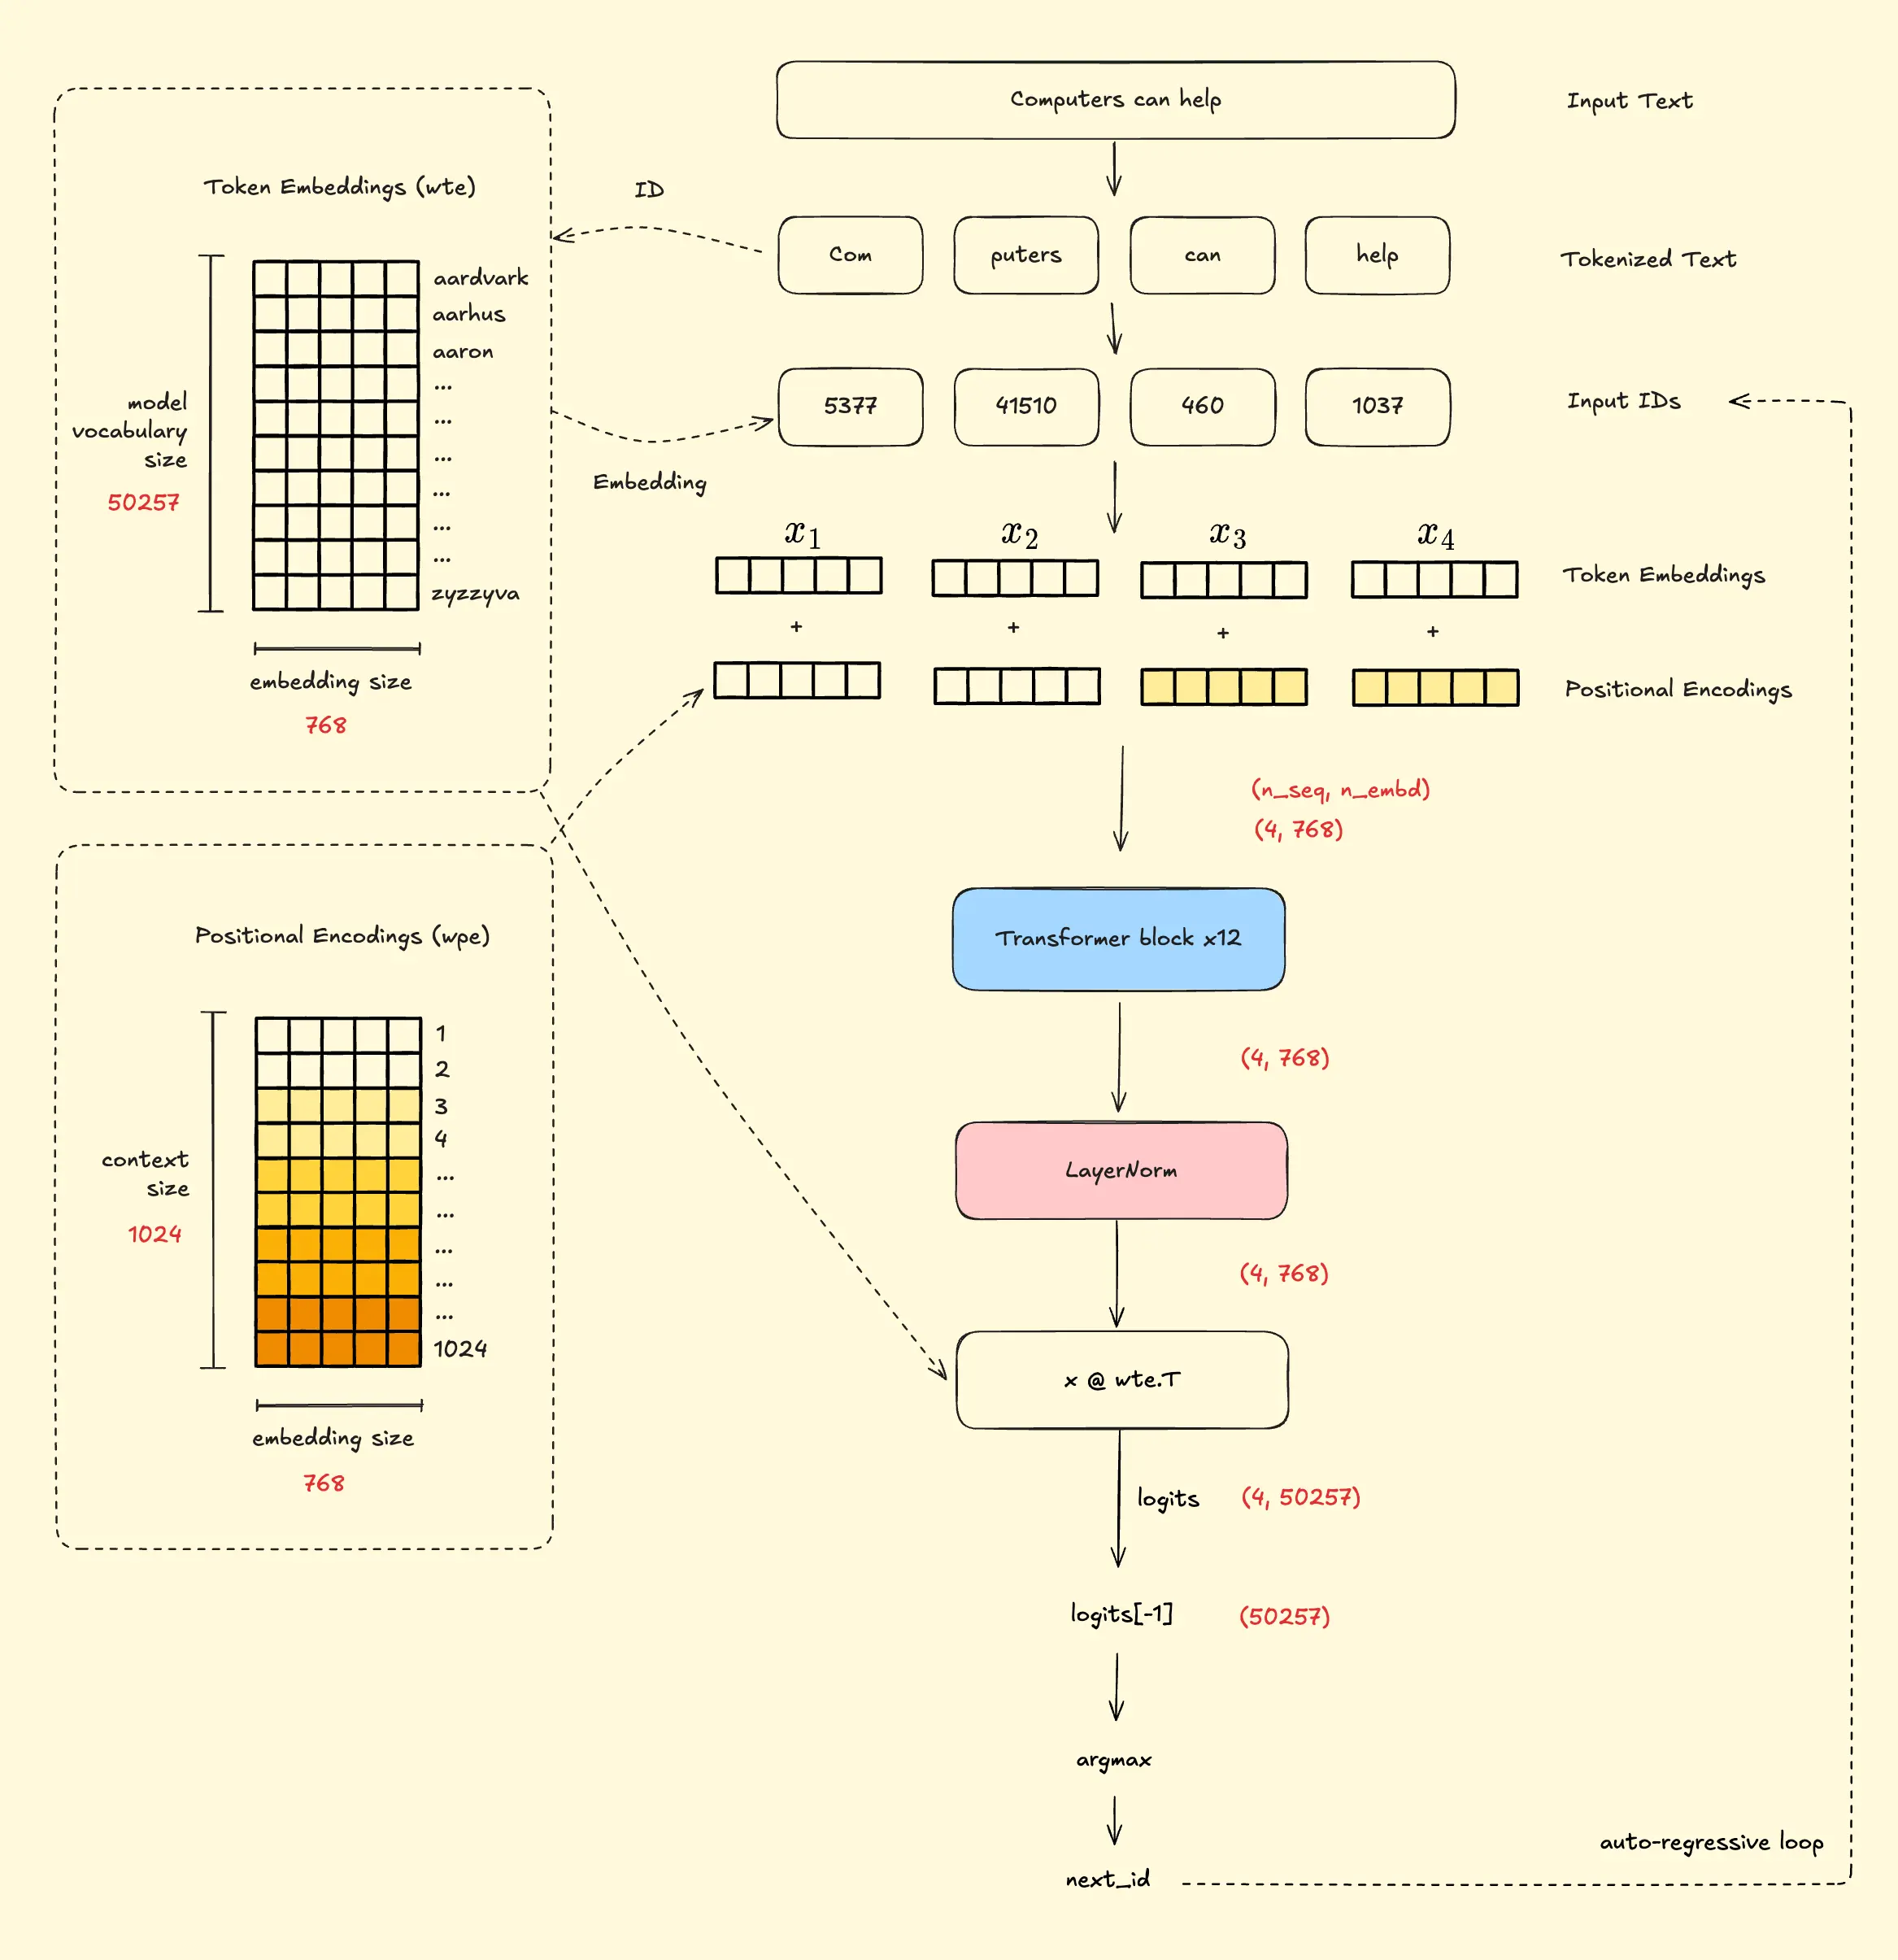

In [ ]:
print(f'Input ids        : {input_ids}')
print(f'Input shape      : list of {len(input_ids)} ints')
print(f'\n--- Forward pass ---')
print(f'wte shape        : {params["wte"].shape}')
print(f'wpe shape        : {params["wpe"].shape}')
print(f'n_layer blocks   : {len(params["blocks"])}')
print(f'ln_f.g shape     : {params["ln_f"]["g"].shape}')
print(f'\nWeight tying: output projection = wte.T  {params["wte"].T.shape}')

logits = gpt2(input_ids, **params, n_head=n_head)
print(f'\nlogits shape     : {logits.shape}  (n_seq × n_vocab)')
print(f'logits[-1] shape : {logits[-1].shape}  ← only this row used for next token')

In [ ]:
# Top-5 predictions for next token
last_logits = logits[-1]
top5_ids = np.argsort(last_logits)[-5:][::-1]

print('Top 5 next-token predictions:')
for rank, idx in enumerate(top5_ids):
    token_str = encoder.decode([int(idx)])
    print(f"  #{rank + 1}  id={idx:>6}  logit={last_logits[idx]:>8.3f}  token='{token_str}'")

next_id = int(np.argmax(last_logits))
print(f"\nGreedy pick (argmax): id={next_id} → '{encoder.decode([next_id])}'")
print(f"Full sequence so far: '{encoder.decode(input_ids + [next_id])}'")